# Etapa 2 — Análisis de Componentes Principales (ACP)

**TPI Ciencia de Datos — DS Airlines**

Este notebook aplica el Análisis de Componentes Principales sobre el subconjunto de los **30.518 clientes** que viajan en vuelos clasificados como demorados (salida del notebook `04_Aplicacion_Arbol_CasosNuevos.ipynb`).

A diferencia de K-Medias, Jerárquico y Bietápico, el ACP no es una técnica de agrupamiento: no asigna clientes a clusters. Cumple dos funciones dentro del trabajo, conforme al enunciado y al material de la cátedra:

1. **Validar la estructura latente** del dataset, confirmando que las seis variables numéricas se organizan en torno a un número reducido de dimensiones independientes.
2. **Proporcionar un espacio bidimensional** sobre el cual proyectar y visualizar los clusters obtenidos por las otras tres técnicas (reducción de dimensionalidad requerida explícitamente por el enunciado).

Se sigue el procedimiento del material de la cátedra: estandarización de las variables (equivalente a trabajar sobre la matriz de correlaciones), evaluación de adecuación mediante KMO y test de esfericidad de Bartlett, extracción de valores y vectores propios, selección de componentes y su interpretación a partir de las cargas.

## 1. Importaciones y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# KMO y Bartlett (instalar si no está disponible en Colab)
!pip install factor_analyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

sns.set_style('whitegrid')
RANDOM_STATE = 42

# Si se ejecuta en Colab, subir manualmente resultados_etapa2_arbol.xlsx
# from google.colab import files
# files.upload()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=5b05e844fa40d447b9cd20273935aafd937af0818a8fd3bd82db27da5a759b78
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


## 2. Carga del dataset de clientes demorados

Se carga la hoja `clientes_a_analizar` del archivo `resultados_etapa2_arbol.xlsx`, que contiene los 30.518 clientes únicos afectados por al menos un vuelo demorado, con todos sus atributos originales.

In [ ]:
clientes = pd.read_excel('resultados_etapa2_arbol.xlsx', sheet_name='clientes_a_analizar')
print(f'Clientes demorados: {clientes.shape}')
clientes.head(3)

Clientes demorados: (30518, 14)


,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
0,1,M,Salta,24,Comerciante,21,Económica,5731.62,1222.62,Sí,19113,1367,3,Agencia
1,2,F,Córdoba,49,Médico,16,Económica,2593.40,510.70,No,0,6252,30,App
2,3,M,Buenos Aires,41,Docente,10,Económica,2850.62,627.01,No,0,1593,16,App


## 3. Preparación de los datos

Se aplica el ACP sobre las **mismas seis variables numéricas** de la vista minable común a las cuatro técnicas: `edad`, `cant_vuelos`, `cantidad_millas`, `ingreso_mensual`, `anticipacion_compra_promedio` y `gasto_acumulado`. El identificador `id_cliente` se conserva aparte para vincular las puntuaciones resultantes con cada cliente.

In [ ]:
cols_numericas = ['edad', 'cant_vuelos', 'cantidad_millas', 'ingreso_mensual',
                  'anticipacion_compra_promedio', 'gasto_acumulado']

id_cliente = clientes['id_cliente'].copy()
X = clientes[cols_numericas].copy()
print(f'Matriz de datos: {X.shape}')
X.describe().round(2)

Matriz de datos: (30518, 6)


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
count,30518.00,30518.00,30518.00,30518.00,30518.00,30518.00
mean,37.83,17.04,6683.51,3088.51,20.06,6556.16
std,11.49,15.78,23156.77,4145.57,21.62,12353.49
min,18.00,1.00,0.00,300.00,0.00,73.19
25%,29.00,6.00,0.00,1248.00,5.00,1400.28
50%,38.00,14.00,0.00,2091.00,13.00,3109.86
75%,46.00,21.00,0.00,3818.00,27.00,6311.94
max,80.00,99.00,541589.00,350075.00,180.00,253140.32


## 4. Estandarización

Cuando las variables están medidas en unidades distintas (años, USD, miles de millas) el ACP debe realizarse sobre datos estandarizados; de lo contrario, las variables de mayor varianza dominarían artificialmente la primera componente. Estandarizar las variables y luego operar sobre su matriz de covarianzas es equivalente a operar sobre la **matriz de correlaciones** de las variables originales, que es el enfoque estándar en este caso.

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=cols_numericas, index=X.index)
print('Tras la estandarización (media ~0, desvío ~1):')
X_scaled.describe().round(4)

Tras la estandarización (media ~0, desvío ~1):


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
count,30518.0000,30518.0000,30518.0000,30518.0000,30518.0000,30518.0000
mean,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.7255,-1.0170,-0.2886,-0.6727,-0.9279,-0.5248
25%,-0.7683,-0.7000,-0.2886,-0.4440,-0.6966,-0.4174
50%,0.0148,-0.1929,-0.2886,-0.2406,-0.3266,-0.2790
75%,0.7110,0.2508,-0.2886,0.1760,0.3210,-0.0198
max,3.6696,5.1952,23.0997,83.7019,7.3984,19.9610


## 5. Adecuación del análisis: KMO y test de esfericidad de Bartlett

Antes de extraer componentes se evalúa si el dataset es apto para el ACP, con los dos indicadores que utiliza la cátedra:

- **Test de esfericidad de Bartlett**: contrasta H₀: la matriz de correlaciones es la identidad (|R| = 1, variables incorrelacionadas) contra Hₐ: |R| ≠ 1. Un p-valor bajo permite rechazar H₀ y habilita el análisis.
- **Medida KMO (Kaiser-Meyer-Olkin)**: cuantifica qué proporción de la varianza entre variables puede ser varianza común. Valores por encima de 0,7 se consideran aceptables.

In [ ]:
chi2, p_value = calculate_bartlett_sphericity(X_scaled)
kmo_por_variable, kmo_total = calculate_kmo(X_scaled)

print('Test de esfericidad de Bartlett:')
print(f'  Chi-cuadrado aproximado = {chi2:,.2f}')
print(f'  p-valor                 = {p_value:.4g}')
print(f'\nMedida KMO global = {kmo_total:.4f}')
print('\nKMO por variable:')
for var, val in zip(cols_numericas, kmo_por_variable):
    print(f'  {var:32s} {val:.3f}')

Test de esfericidad de Bartlett:
  Chi-cuadrado aproximado = 33,038.38
  p-valor                 = 0

Medida KMO global = 0.7436

KMO por variable:
  edad                             0.687
  cant_vuelos                      0.730
  cantidad_millas                  0.787
  ingreso_mensual                  0.830
  anticipacion_compra_promedio     0.749
  gasto_acumulado                  0.702


## 6. Extracción de componentes

Se calculan los valores propios (autovalores) y los vectores propios de la matriz de correlaciones. Cada autovalor representa la varianza capturada por su componente; como las variables están estandarizadas, la varianza total es igual al número de variables (6), de modo que cada autovalor puede leerse directamente como "número de variables equivalentes" que explica el componente.

In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

autovalores = pca_full.explained_variance_
var_pct = pca_full.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_pct)

tabla_var = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(autovalores))],
    'Autovalor': autovalores.round(4),
    '% Varianza': var_pct.round(3),
    '% Acumulado': var_acum.round(3)
})
print('Varianza total explicada:')
print(tabla_var.to_string(index=False))

Varianza total explicada:
Componente  Autovalor  % Varianza  % Acumulado
       PC1     2.3585      39.306       39.306
       PC2     1.0537      17.561       56.867
       PC3     0.9231      15.384       72.252
       PC4     0.7881      13.135       85.386
       PC5     0.5081       8.467       93.854
       PC6     0.3688       6.146      100.000


## 7. Selección del número de componentes

Se consideran los criterios habituales:

- **Criterio de Kaiser** (autovalor > 1): retiene los componentes que explican más varianza que una variable original estandarizada.
- **Criterio del 80% de varianza acumulada** (umbral orientativo utilizado por la cátedra).

En este dataset Kaiser arroja dos componentes (PC1 con autovalor 2,359 y PC2 con 1,054), mientras que el criterio del 80% requeriría cuatro (con PC4 se llega a 85,39%). Ambos criterios entran en tensión. Se adopta como solución de compromiso retener **los tres primeros componentes**, que acumulan el 72,25% de la varianza, por dos motivos: PC3 tiene un autovalor de 0,923 muy próximo al umbral de Kaiser y aporta un 15,38% adicional sobre PC1 y PC2, y la proyección sobre tres dimensiones sigue siendo representable visualmente. Esta elección queda más cerca del 80% que la solución de dos componentes sin recurrir a cuatro, donde los aportes marginales son menores y la interpretabilidad disminuye.

In [ ]:
n_kaiser = int((autovalores > 1).sum())
n_80 = int(np.argmax(var_acum >= 80) + 1)

print(f'Componentes con autovalor > 1 (Kaiser): {n_kaiser}')
print(f'Componentes para alcanzar el 80% de varianza acumulada: {n_80} '
      f'({var_acum[n_80-1]:.2f}%)')
print(f'\nVarianza acumulada con 2 componentes: {var_acum[1]:.2f}%')
print(f'Varianza acumulada con 3 componentes (solución adoptada): {var_acum[2]:.2f}%')

Componentes con autovalor > 1 (Kaiser): 2
Componentes para alcanzar el 80% de varianza acumulada: 4 (85.39%)

Varianza acumulada con 2 componentes: 56.87%
Varianza acumulada con 3 componentes (solución adoptada): 72.25%


### Scree plot

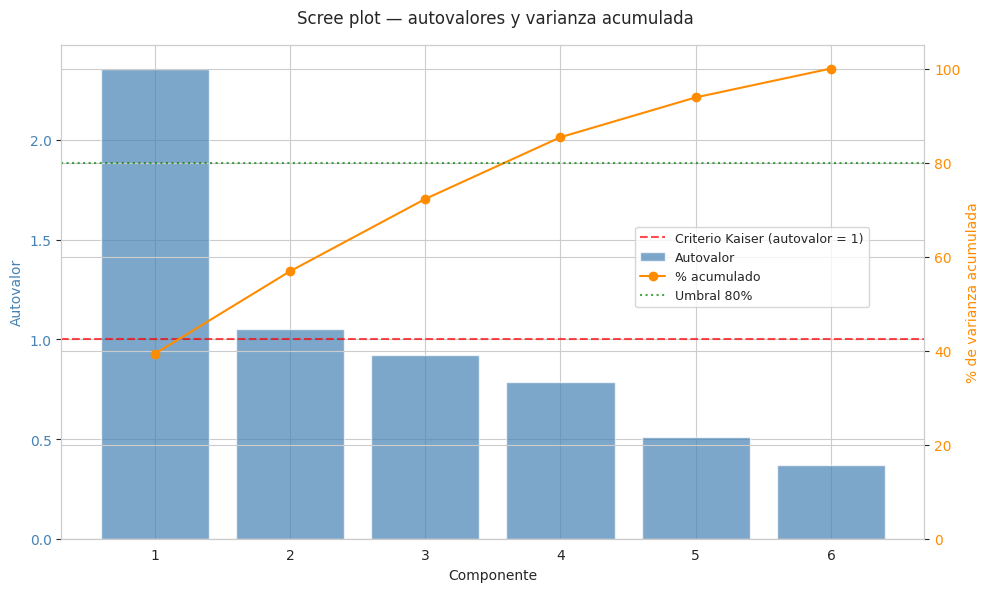

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
componentes = np.arange(1, len(autovalores) + 1)

ax1.bar(componentes, autovalores, color='steelblue', alpha=0.7, label='Autovalor')
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Criterio Kaiser (autovalor = 1)')
ax1.set_xlabel('Componente')
ax1.set_ylabel('Autovalor', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(componentes, var_acum, 'o-', color='darkorange', label='% acumulado')
ax2.axhline(y=80, color='green', linestyle=':', alpha=0.7, label='Umbral 80%')
ax2.set_ylabel('% de varianza acumulada', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)

fig.suptitle('Scree plot — autovalores y varianza acumulada')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.55), fontsize=9)
plt.tight_layout()
plt.show()

## 8. Matriz de componentes (vectores propios)

Los vectores propios contienen los coeficientes que ponderan cada variable original en cada componente. Permiten interpretar conceptualmente a qué se refiere cada eje. Se muestran los componentes retenidos para visualización (PC1 y PC2) y, a modo de referencia, también PC3 y PC4.

In [ ]:
componentes_df = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(autovalores))],
    index=cols_numericas
)
print('Vectores propios (cargas de cada variable sobre cada componente):')
componentes_df.iloc[:, :4].round(3)

Vectores propios (cargas de cada variable sobre cada componente):


,PC1,PC2,PC3,PC4
edad,0.114,0.706,0.674,-0.168
cant_vuelos,0.535,-0.023,-0.026,-0.218
cantidad_millas,0.491,-0.165,-0.062,-0.341
ingreso_mensual,0.375,-0.007,0.160,0.892
anticipacion_compra_promedio,-0.116,-0.679,0.718,-0.081
gasto_acumulado,0.553,-0.114,-0.017,-0.075


## 9. Interpretación de los componentes

A partir de las cargas se interpreta el significado de los tres primeros componentes, que son los que se retienen como solución del análisis.

In [ ]:
for pc in ['PC1', 'PC2', 'PC3']:
    cargas = componentes_df[pc].sort_values(key=abs, ascending=False)
    print(f'\n{pc} (explica {var_pct[int(pc[2:])-1]:.2f}% de la varianza) — cargas ordenadas por magnitud:')
    for var, val in cargas.items():
        print(f'  {var:32s} {val:+.3f}')


PC1 (explica 39.31% de la varianza) — cargas ordenadas por magnitud:
  gasto_acumulado                  +0.553
  cant_vuelos                      +0.535
  cantidad_millas                  +0.491
  ingreso_mensual                  +0.375
  anticipacion_compra_promedio     -0.116
  edad                             +0.114

PC2 (explica 17.56% de la varianza) — cargas ordenadas por magnitud:
  edad                             +0.706
  anticipacion_compra_promedio     -0.679
  cantidad_millas                  -0.165
  gasto_acumulado                  -0.114
  cant_vuelos                      -0.023
  ingreso_mensual                  -0.007

PC3 (explica 15.38% de la varianza) — cargas ordenadas por magnitud:
  anticipacion_compra_promedio     +0.718
  edad                             +0.674
  ingreso_mensual                  +0.160
  cantidad_millas                  -0.062
  cant_vuelos                      -0.026
  gasto_acumulado                  -0.017


**Lectura de los componentes:**

- **PC1 — eje del valor económico del cliente**: cargas positivas y elevadas en `gasto_acumulado`, `cant_vuelos`, `cantidad_millas` e `ingreso_mensual`. Las puntuaciones altas identifican a los pasajeros comercialmente más activos.
- **PC2 — eje generacional contrapuesto**: cargas de signo opuesto en `edad` (positiva) y `anticipacion_compra_promedio` (negativa). Separa a los pasajeros mayores que compran con poca anticipación de los más jóvenes que planifican con mayor antelación.
- **PC3 — eje generacional concordante**: cargas positivas y elevadas en `anticipacion_compra_promedio` (0,718) y `edad` (0,674), mientras que las variables económicas aportan en magnitudes despreciables. A diferencia de PC2, en este componente ambas variables se mueven en el mismo sentido: en su polo positivo se ubican los pasajeros de mayor edad que además compran con mucha anticipación, y en su polo negativo los más jóvenes que compran sobre la fecha. Es un eje secundario del perfil generacional-temporal, ortogonal a PC2.

Esta interpretación coincide con la obtenida en el ACP exploratorio realizado en SPSS sobre el dataset original, confirmando que la estructura latente es estable.

## 10. Cálculo de las puntuaciones y visualización

Se proyectan los 30.518 clientes sobre los tres primeros componentes. Las puntuaciones sobre PC1 y PC2 son las que se reutilizan como espacio de visualización bidimensional en los notebooks de K-Medias, Cluster Jerárquico y Bietápico. Las puntuaciones sobre PC3 se conservan en el archivo de salida y se grafican aquí en una proyección tridimensional para ilustrar la estructura completa de la solución adoptada.

In [ ]:
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
scores = pca3.fit_transform(X_scaled)

scores_df = pd.DataFrame(scores, columns=['PC1', 'PC2', 'PC3'], index=X.index)
scores_df.insert(0, 'id_cliente', id_cliente.values)

print(f'Puntuaciones calculadas: {scores_df.shape}')
scores_df.head()

Puntuaciones calculadas: (30518, 4)


,id_cliente,PC1,PC2,PC3
0,1,0.158800,-0.397078,-1.483179
1,2,-0.010417,0.453920,1.132689
2,3,-0.628400,0.417021,0.028229
3,4,-1.117737,-1.903903,-0.260004
4,5,-0.327315,-0.548907,-0.188918


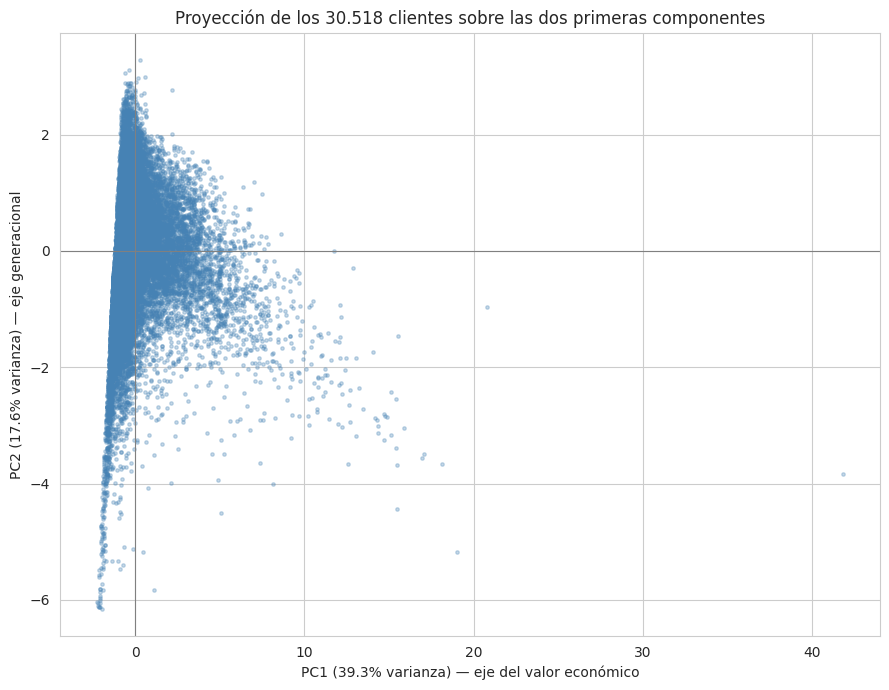

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(scores_df['PC1'], scores_df['PC2'], s=6, alpha=0.3, color='steelblue')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel(f'PC1 ({var_pct[0]:.1f}% varianza) — eje del valor económico')
plt.ylabel(f'PC2 ({var_pct[1]:.1f}% varianza) — eje generacional')
plt.title('Proyección de los 30.518 clientes sobre las dos primeras componentes')
plt.tight_layout()
plt.show()

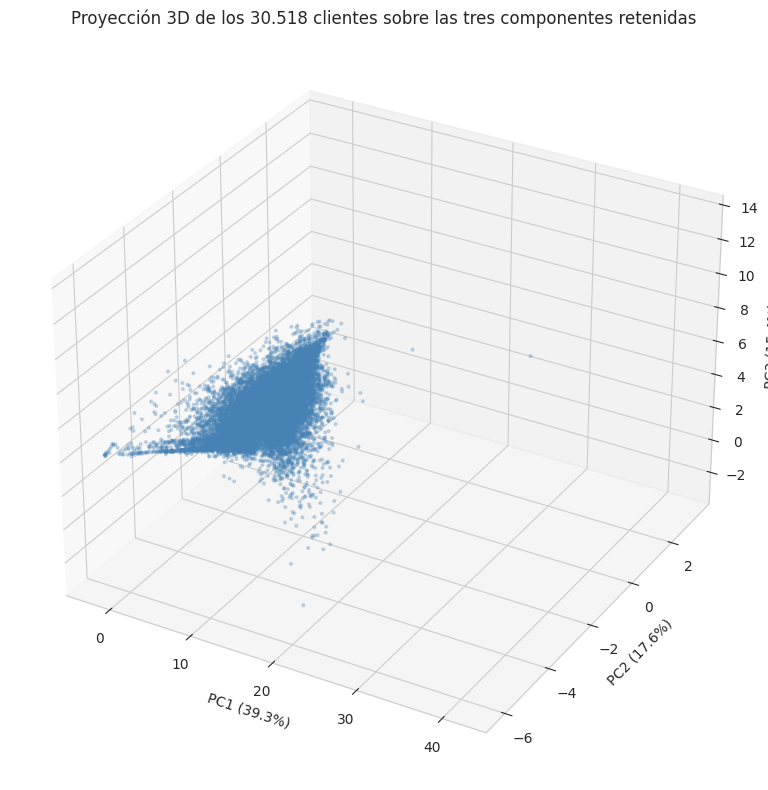

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(scores_df['PC1'], scores_df['PC2'], scores_df['PC3'],
           s=4, alpha=0.25, color='steelblue')
ax.set_xlabel(f'PC1 ({var_pct[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_pct[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({var_pct[2]:.1f}%)')
ax.set_title('Proyección 3D de los 30.518 clientes sobre las tres componentes retenidas')
plt.tight_layout()
plt.show()

El gráfico muestra la nube de clientes en el plano de los dos primeros componentes. La masa principal se concentra en torno al origen, con una cola hacia la derecha (PC1 alto) correspondiente a los pasajeros de mayor valor económico, y una dispersión vertical sobre PC2 que recoge la diferencia generacional. Esta es la representación bidimensional que se reutiliza en K-Medias, Jerárquico y Bietápico para colorear los clusters obtenidos por cada técnica.

## 11. Biplot: variables y observaciones

El biplot superpone las direcciones de las variables originales sobre el plano de componentes, lo que facilita leer simultáneamente cómo se ubican los clientes y hacia dónde "apunta" cada variable.

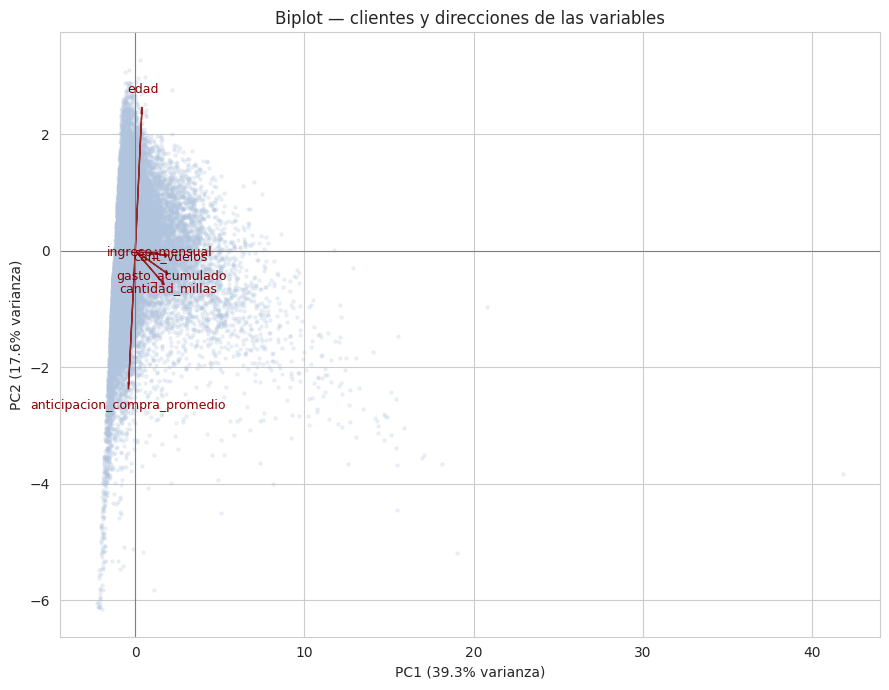

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(scores_df['PC1'], scores_df['PC2'], s=5, alpha=0.2, color='lightsteelblue')

# Vectores de las variables (cargas escaladas para visualización)
escala = 3.5
for var in cols_numericas:
    vx = componentes_df.loc[var, 'PC1'] * escala
    vy = componentes_df.loc[var, 'PC2'] * escala
    plt.arrow(0, 0, vx, vy, color='darkred', alpha=0.8, head_width=0.08, length_includes_head=True)
    plt.text(vx * 1.12, vy * 1.12, var, color='darkred', fontsize=9, ha='center', va='center')

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel(f'PC1 ({var_pct[0]:.1f}% varianza)')
plt.ylabel(f'PC2 ({var_pct[1]:.1f}% varianza)')
plt.title('Biplot — clientes y direcciones de las variables')
plt.tight_layout()
plt.show()

## 12. Exportación de resultados

Se guarda un archivo Excel con:

- **`puntuaciones_pca`**: las puntuaciones PC1, PC2 y PC3 de cada cliente (con su id_cliente). PC1 y PC2 son las que se utilizan como espacio de visualización en los notebooks de clustering; PC3 se conserva como tercera dimensión de la solución adoptada.
- **`varianza_explicada`**: tabla de autovalores y porcentajes por componente.
- **`vectores_propios`**: matriz de cargas de cada variable sobre cada componente.

In [ ]:
archivo_salida = 'resultados_acp.xlsx'

with pd.ExcelWriter(archivo_salida, engine='openpyxl') as writer:
    scores_df.to_excel(writer, sheet_name='puntuaciones_pca', index=False)
    tabla_var.to_excel(writer, sheet_name='varianza_explicada', index=False)
    componentes_df.to_excel(writer, sheet_name='vectores_propios')

print(f'Archivo generado: {archivo_salida}')
print(f'  - puntuaciones_pca:   {len(scores_df)} filas')
print(f'  - varianza_explicada: {len(tabla_var)} filas')
print(f'  - vectores_propios:   {len(componentes_df)} filas')

Archivo generado: resultados_acp.xlsx
  - puntuaciones_pca:   30518 filas
  - varianza_explicada: 6 filas
  - vectores_propios:   6 filas


## 13. Cierre

El ACP confirma que las seis variables numéricas del dataset de clientes demorados se organizan en torno a dos ejes latentes principales (un eje económico capturado por PC1 y un eje generacional contrapuesto capturado por PC2) y un eje secundario de menor peso (PC3) que recoge la variación remanente entre edad y anticipación de compra cuando se mueven en el mismo sentido. El KMO global y el test de Bartlett validan la pertinencia de la técnica sobre este dataset.

Como solución de compromiso entre el criterio de Kaiser (que arroja dos componentes) y el criterio del 80% de varianza acumulada (que requeriría cuatro), se retienen los tres primeros componentes, que acumulan el 72,25% de la variabilidad total. PC1 y PC2 alimentan las visualizaciones bidimensionales de los clusters obtenidos por K-Medias, Cluster Jerárquico y Bietápico, mientras que PC3 se conserva como tercera dimensión de la solución del ACP, sin reutilizarse para los gráficos de las otras técnicas. El ACP no produce una segmentación propia, sino que opera como técnica transversal de validación de estructura y reducción de dimensionalidad.